In [21]:
from datetime import date, timedelta
import pandas as pd

In [39]:
DOW_MAP = {
    "MONDAY": 0, "mon": 0,
    "TUESDAY": 1, "tue": 1,
    "WEDNESDAY": 2, "wed": 2,
    "THURSDAY": 3, "thu": 3,
    "FRIDAY": 4, "fri": 4,
    "SATURDAY": 5, "sat": 5,
    "SUNDAY": 6, "sun": 6,
}

def normalize_dow(s):
    return DOW_MAP[str(s).strip().upper()]

def reconstruct_fuzzy_backward(months, dows, end_date, window=10):
    cur = end_date
    out = [None] * len(months)
    bad_rows = []

    for i in range(len(months) - 1, -1, -1):
        best = None
        best_dist = None

        for delta in range(-window, window + 1):
            probe = cur + timedelta(days=delta)
            if probe.month == months[i] and probe.weekday() == dows[i]:
                dist = abs(delta)
                if best is None or dist < best_dist:
                    best = probe
                    best_dist = dist

        if best is None:
            # skip this row
            bad_rows.append(i)
            out[i] = None
            continue

        out[i] = best
        cur = best  # only re-anchor on success

    return out, bad_rows



In [40]:
df = pd.read_csv("data/all_paths_128.csv", sep=";")
df

,time_range,day_of_week,month,mode_of_transport,geohash,direction
0,18-21,TUESDAY,8,BUS,u0m70dcm,EAST
1,18-21,TUESDAY,8,BUS,u0m70ddq,NORTH_WEST
2,18-21,TUESDAY,8,BUS,u0m70dfh,EAST
3,6-9,WEDNESDAY,8,ON_BICYCLE,u0m70fqv,NORTH_EAST
4,6-9,WEDNESDAY,8,ON_BICYCLE,u0m70fqk,EAST
...,...,...,...,...,...,...
1466832,13-14,TUESDAY,12,ON_BICYCLE,u0m70fm3c,WEST
1466833,13-14,TUESDAY,12,ON_BICYCLE,u0m70dr8z,SOUTH_WEST
1466834,13-14,TUESDAY,12,ON_BICYCLE,u0m70f6c9,WEST
1466835,13-14,TUESDAY,12,ON_BICYCLE,u0m70fk3c,WEST


In [44]:

df["dow_num"] = df["day_of_week"].map(normalize_dow)

dates, bad = reconstruct_fuzzy_backward(
    df["month"].to_numpy(),
    df["dow_num"].to_numpy(),
    end_date=date.today()
)

df["date"] = pd.to_datetime(dates, errors="coerce")
df["bad_date"] = df["date"].isna()

# remove them
df_clean = df[~df["bad_date"]]

In [45]:
df["date"].diff().abs().dt.days.describe()

count    1.445307e+06
mean     2.982757e-03
std      8.402496e-02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+01
Name: date, dtype: float64

In [47]:
df_clean

,time_range,day_of_week,month,mode_of_transport,geohash,direction,dow_num,date,bad_date
0,18-21,TUESDAY,8,BUS,u0m70dcm,EAST,1,2024-08-13,False
1,18-21,TUESDAY,8,BUS,u0m70ddq,NORTH_WEST,1,2024-08-13,False
2,18-21,TUESDAY,8,BUS,u0m70dfh,EAST,1,2024-08-13,False
3,6-9,WEDNESDAY,8,ON_BICYCLE,u0m70fqv,NORTH_EAST,2,2024-08-14,False
4,6-9,WEDNESDAY,8,ON_BICYCLE,u0m70fqk,EAST,2,2024-08-14,False
...,...,...,...,...,...,...,...,...,...
1466832,13-14,TUESDAY,12,ON_BICYCLE,u0m70fm3c,WEST,1,2025-12-16,False
1466833,13-14,TUESDAY,12,ON_BICYCLE,u0m70dr8z,SOUTH_WEST,1,2025-12-16,False
1466834,13-14,TUESDAY,12,ON_BICYCLE,u0m70f6c9,WEST,1,2025-12-16,False
1466835,13-14,TUESDAY,12,ON_BICYCLE,u0m70fk3c,WEST,1,2025-12-16,False


In [48]:
# Remove bad dates
df_clean = df[~df["bad_date"]]
df_clean

,time_range,day_of_week,month,mode_of_transport,geohash,direction,dow_num,date,bad_date
0,18-21,TUESDAY,8,BUS,u0m70dcm,EAST,1,2024-08-13,False
1,18-21,TUESDAY,8,BUS,u0m70ddq,NORTH_WEST,1,2024-08-13,False
2,18-21,TUESDAY,8,BUS,u0m70dfh,EAST,1,2024-08-13,False
3,6-9,WEDNESDAY,8,ON_BICYCLE,u0m70fqv,NORTH_EAST,2,2024-08-14,False
4,6-9,WEDNESDAY,8,ON_BICYCLE,u0m70fqk,EAST,2,2024-08-14,False
...,...,...,...,...,...,...,...,...,...
1466832,13-14,TUESDAY,12,ON_BICYCLE,u0m70fm3c,WEST,1,2025-12-16,False
1466833,13-14,TUESDAY,12,ON_BICYCLE,u0m70dr8z,SOUTH_WEST,1,2025-12-16,False
1466834,13-14,TUESDAY,12,ON_BICYCLE,u0m70f6c9,WEST,1,2025-12-16,False
1466835,13-14,TUESDAY,12,ON_BICYCLE,u0m70fk3c,WEST,1,2025-12-16,False


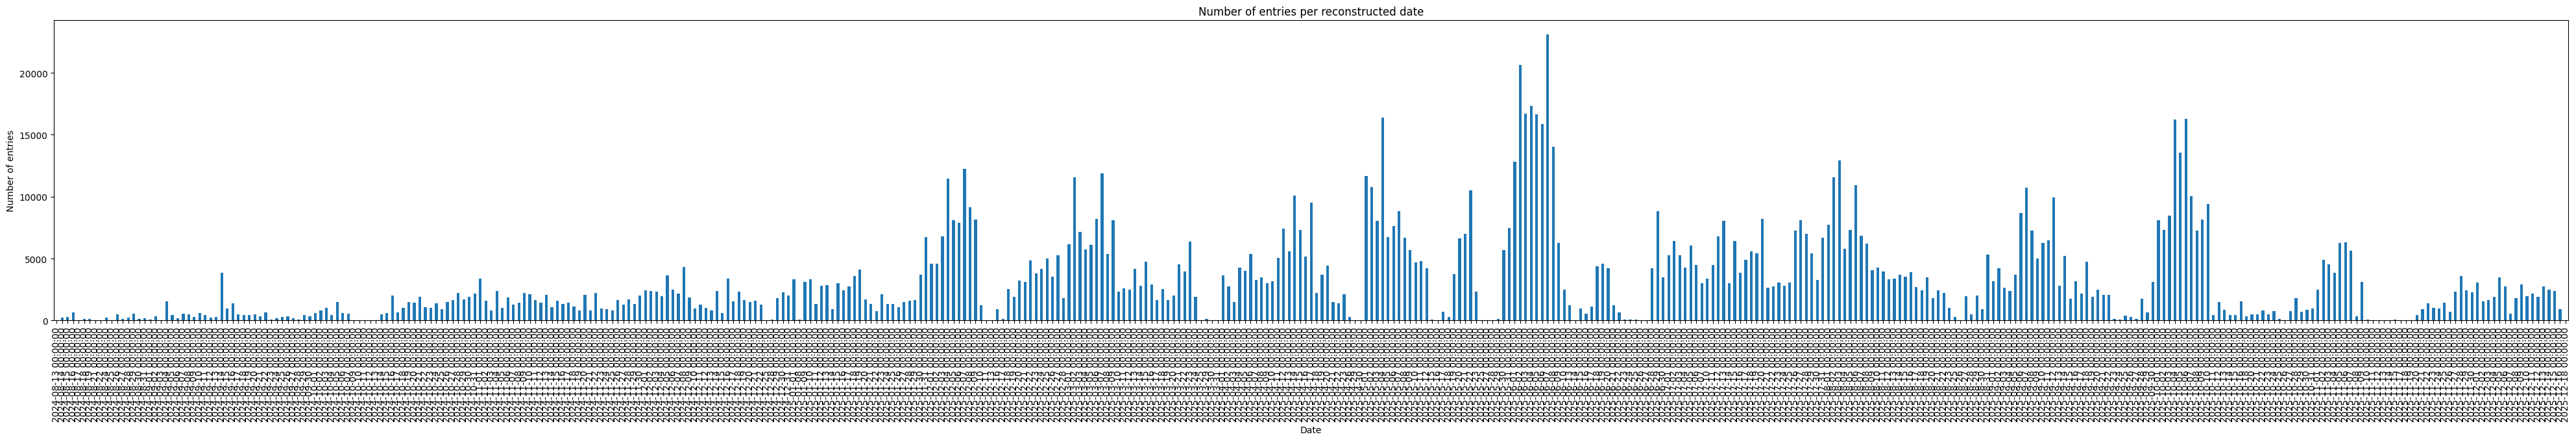

In [50]:
# Plot number of entries per date
import matplotlib.pyplot as plt
df_clean.groupby("date").size().plot(kind="bar", figsize=(50, 6))
plt.xlabel("Date")
plt.ylabel("Number of entries")
plt.title("Number of entries per reconstructed date")
plt.show()

In [51]:
# Save to csv
df_clean.to_csv("data/all_paths_128_cleaned.csv", sep=";", index=False)